In [1]:
!pip install tensorflow keras numpy matplotlib seaborn pandas scikit-learn opencv-python split-folders


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from splitfolders import ratio

ratio(
    "../dataset",
    output="../processed_dataset",
    seed=42,
    ratio=(0.7, 0.15, 0.15)
)

print("Dataset Split Successfully!")

Copying files: 0 files [00:00, ? files/s]

Copying files: 54305 files [02:08, 422.93 files/s]

Dataset Split Successfully!


In [2]:
import os

print(os.listdir("../processed_dataset"))

['test', 'train', 'val']


In [3]:
train_dir = "../processed_dataset/train"

print(os.listdir(train_dir))

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import load_model

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
train_dir = "../processed_dataset/train"
valid_dir = "../processed_dataset/val"
test_dir = "../processed_dataset/test"

In [3]:
IMG_SIZE = 224
BATCH_SIZE = 32

In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
    brightness_range=[0.8,1.2]
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [5]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

valid_data = test_datagen.flow_from_directory(
    valid_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 37997 images belonging to 38 classes.
Found 8129 images belonging to 38 classes.
Found 8179 images belonging to 38 classes.


In [6]:
print("Total Classes:", train_data.num_classes)

Total Classes: 38


In [10]:
print(train_data.class_indices)

{'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30, 'Tomato

In [11]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [12]:
for layer in base_model.layers:
    layer.trainable = False

In [13]:
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(256, activation='relu'),
    Dropout(0.3),

    Dense(train_data.num_classes, activation='softmax')

])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,777,894 (94.52 MB)

 Trainable params: 1,190,182 (4.54 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [16]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "../models/best_resnet50.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [17]:
history = model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2759s 2s/step - accuracy: 0.1122 - loss: 3.3688 - val_accuracy: 0.1767 - val_loss: 3.1752 - learning_rate: 1.0000e-04
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 3638s 3s/step - accuracy: 0.1592 - loss: 3.1761 - val_accuracy: 0.2158 - val_loss: 2.9856 - learning_rate: 1.0000e-04
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2289s 2s/step - accuracy: 0.2004 - loss: 3.0529 - val_accuracy: 0.2612 - val_loss: 2.8183 - learning_rate: 1.0000e-04
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2371s 2s/step - accuracy: 0.2299 - loss: 2.9231 - val_accuracy: 0.2828 - val_loss: 2.7746 - learning_rate: 1.0000e-04
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2346s 2s/step - accuracy: 0.2515 - loss: 2.8023 - val_accuracy: 0.3045 - val_loss: 2.5710 - learning_rate: 1.0000e-04
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2308s 2s/step - accuracy: 0.2689 - loss: 2.7053 - val_accuracy: 0.2795 - val_loss: 2.6255 - learning_rate: 1.0000e-04
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━

In [18]:
print(train_data.num_classes)

38


In [8]:
model = load_model("../models/best_resnet50.keras")

In [9]:
for layer in model.layers[0].layers[:-30]:
    layer.trainable = False

for layer in model.layers[0].layers[-30:]:
    layer.trainable = True

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "../models/best_resnet50.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [12]:
history_finetune = model.fit(
    train_data,
    validation_data=valid_data,
    initial_epoch=10,
    epochs=13,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 11/13
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 3259s 3s/step - accuracy: 0.3323 - loss: 2.6611 - val_accuracy: 0.3551 - val_loss: 2.5492 - learning_rate: 1.0000e-05
Epoch 12/13
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 3242s 3s/step - accuracy: 0.4182 - loss: 2.1149 - val_accuracy: 0.4654 - val_loss: 2.0168 - learning_rate: 1.0000e-05
Epoch 13/13
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 3140s 3s/step - accuracy: 0.4605 - loss: 1.9434 - val_accuracy: 0.4454 - val_loss: 1.9777 - learning_rate: 1.0000e-05


In [13]:
loss, accuracy = model.evaluate(test_data)

print("Test Accuracy:", accuracy)

256/256 ━━━━━━━━━━━━━━━━━━━━ 452s 2s/step - accuracy: 0.4438 - loss: 1.9622
Test Accuracy: 0.4438195526599884


In [15]:
predictions = model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

256/256 ━━━━━━━━━━━━━━━━━━━━ 432s 2s/step


In [16]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=test_data.class_indices.keys()
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.00      0.00      0.00        95
                                 Apple___Black_rot       0.00      0.00      0.00        94
                          Apple___Cedar_apple_rust       0.00      0.00      0.00        42
                                   Apple___healthy       0.35      0.30      0.32       248
                               Blueberry___healthy       0.42      0.52      0.47       226
          Cherry_(including_sour)___Powdery_mildew       0.67      0.03      0.05       159
                 Cherry_(including_sour)___healthy       0.65      0.25      0.36       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.27      0.58      0.37        78
                       Corn_(maize)___Common_rust_       0.66      0.98      0.79       180
               Corn_(maize)___Northern_Leaf_Blight       0.47      0.18      0.

c:\Users\Sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sumit\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [18]:
import os

os.makedirs("../reports", exist_ok=True)

In [19]:
with open("../reports/resnet50_classification_report.txt", "w") as f:
    f.write(report)

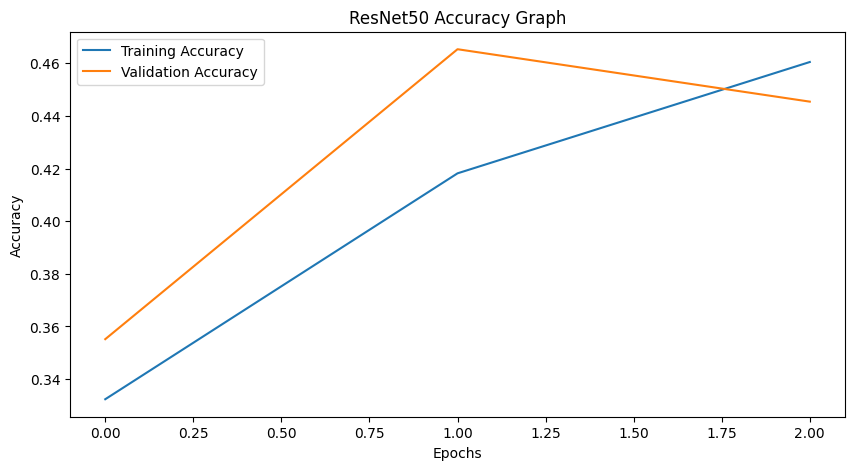

In [21]:
plt.figure(figsize=(10,5))

plt.plot(history_finetune.history['accuracy'], label='Training Accuracy')
plt.plot(history_finetune.history['val_accuracy'], label='Validation Accuracy')

plt.title('ResNet50 Accuracy Graph')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

plt.savefig("../graphs/resnet50_accuracy.png")

plt.show()

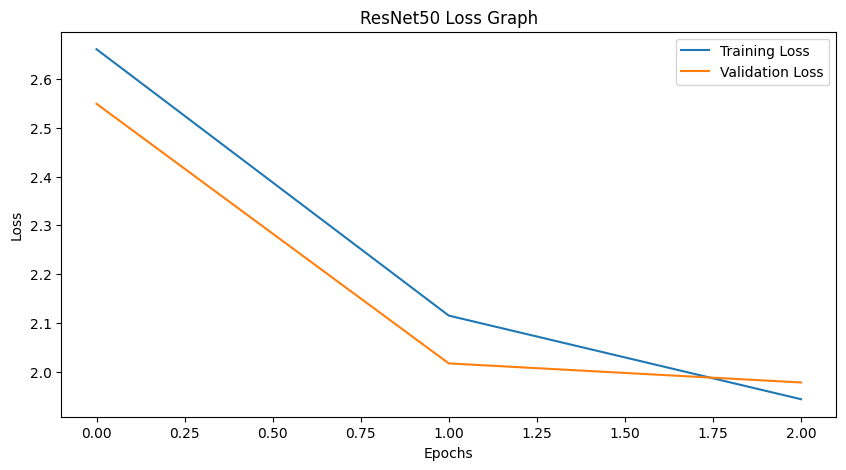

In [22]:
plt.figure(figsize=(10,5))

plt.plot(history_finetune.history['loss'], label='Training Loss')
plt.plot(history_finetune.history['val_loss'], label='Validation Loss')

plt.title('ResNet50 Loss Graph')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.savefig("../graphs/resnet50_loss.png")

plt.show()

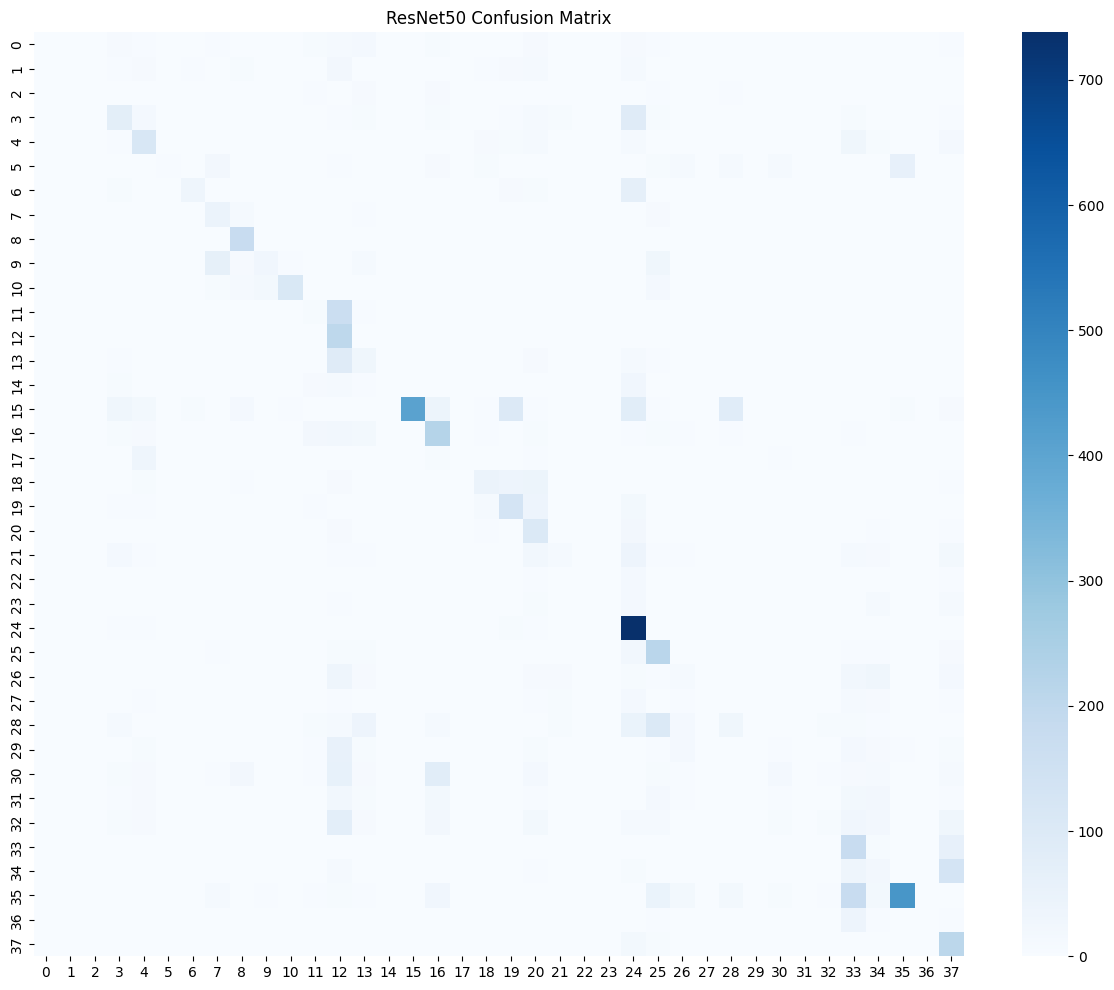

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15,12))

sns.heatmap(cm, cmap='Blues')

plt.title("ResNet50 Confusion Matrix")

plt.savefig("../graphs/resnet50_confusion_matrix.png")

plt.show()

In [25]:
history_df = pd.DataFrame(history_finetune.history)

history_df.to_csv("../reports/resnet50_training_history.csv", index=False)

MobileNetV2

In [9]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [10]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 11s 1us/step


In [11]:
for layer in base_model.layers:
    layer.trainable = False

In [12]:
mobilenet_model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(train_data.num_classes, activation='softmax')
])

In [13]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

checkpoint = ModelCheckpoint(
    "../models/best_mobilenetv2.keras",
    monitor='val_accuracy',
    save_best_only=True
)

In [15]:
mobilenet_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:
history_mobile = mobilenet_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1282s 1s/step - accuracy: 0.6050 - loss: 1.5165 - val_accuracy: 0.8332 - val_loss: 0.6774 - learning_rate: 1.0000e-04
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1236s 1s/step - accuracy: 0.8065 - loss: 0.6795 - val_accuracy: 0.8772 - val_loss: 0.4454 - learning_rate: 1.0000e-04
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1351s 1s/step - accuracy: 0.8531 - loss: 0.5048 - val_accuracy: 0.9033 - val_loss: 0.3426 - learning_rate: 1.0000e-04
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1378s 1s/step - accuracy: 0.8765 - loss: 0.4180 - val_accuracy: 0.9172 - val_loss: 0.2894 - learning_rate: 1.0000e-04
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1198s 1s/step - accuracy: 0.8881 - loss: 0.3652 - val_accuracy: 0.9199 - val_loss: 0.2645 - learning_rate: 1.0000e-04
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1171s 986ms/step - accuracy: 0.9010 - loss: 0.3223 - val_accuracy: 0.9259 - val_loss: 0.2415 - learning_rate: 1.0000e-04
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━

In [17]:
loss, accuracy = mobilenet_model.evaluate(test_data)

print("MobileNetV2 Test Accuracy:", accuracy)

256/256 ━━━━━━━━━━━━━━━━━━━━ 205s 798ms/step - accuracy: 0.9413 - loss: 0.1872
MobileNetV2 Test Accuracy: 0.9413131475448608


In [20]:
predictions = mobilenet_model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

256/256 ━━━━━━━━━━━━━━━━━━━━ 199s 775ms/step


In [19]:
predictions = mobilenet_model.predict(test_data)

y_pred = np.argmax(predictions, axis=1)
y_true = test_data.classes

# from sklearn.metrics import classification_report

mobile_report = classification_report(
    y_true,
    y_pred,
    target_names=test_data.class_indices.keys()
)

print(mobile_report)

256/256 ━━━━━━━━━━━━━━━━━━━━ 181s 706ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.95      0.93      0.94        95
                                 Apple___Black_rot       0.92      0.94      0.93        94
                          Apple___Cedar_apple_rust       0.97      0.93      0.95        42
                                   Apple___healthy       0.99      0.96      0.97       248
                               Blueberry___healthy       0.99      0.98      0.98       226
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       159
                 Cherry_(including_sour)___healthy       0.98      0.98      0.98       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.75      0.77      0.76        78
                       Corn_(maize)___Common_rust_       0.97      0.99      0.98       180
               Corn_(maize)___Nort

In [21]:
with open("../reports/mobilenetv2_classification_report.txt", "w") as f:
    f.write(mobile_report)

In [22]:
history_df = pd.DataFrame(history_mobile.history)

history_df.to_csv(
    "../reports/mobilenetv2_training_history.csv",
    index=False
)

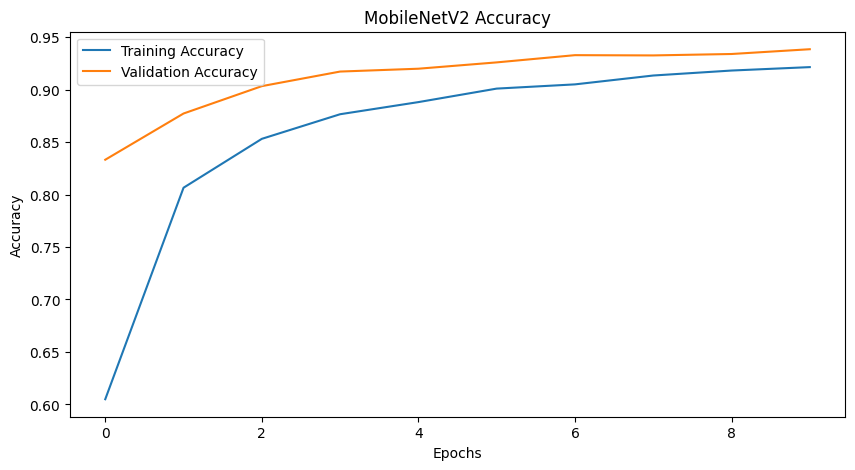

In [23]:
plt.figure(figsize=(10,5))

plt.plot(history_mobile.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobile.history['val_accuracy'], label='Validation Accuracy')

plt.title('MobileNetV2 Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.savefig("../graphs/mobilenetv2_accuracy.png")

plt.show()

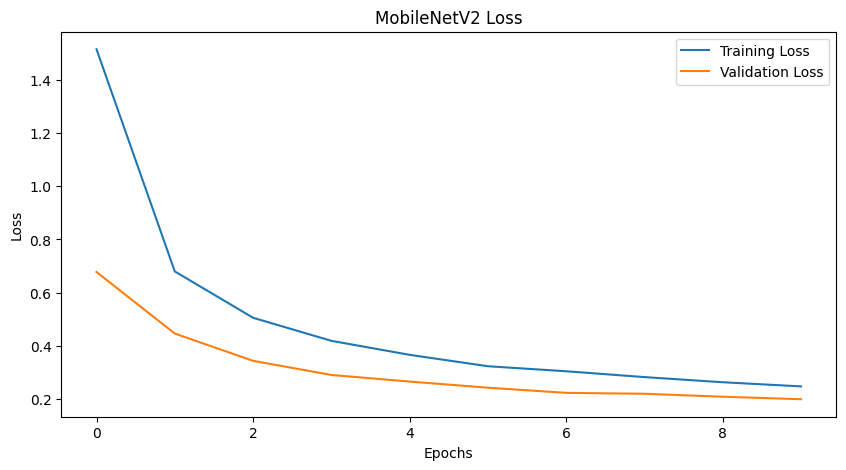

In [24]:
plt.figure(figsize=(10,5))

plt.plot(history_mobile.history['loss'], label='Training Loss')
plt.plot(history_mobile.history['val_loss'], label='Validation Loss')

plt.title('MobileNetV2 Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.savefig("../graphs/mobilenetv2_loss.png")

plt.show()

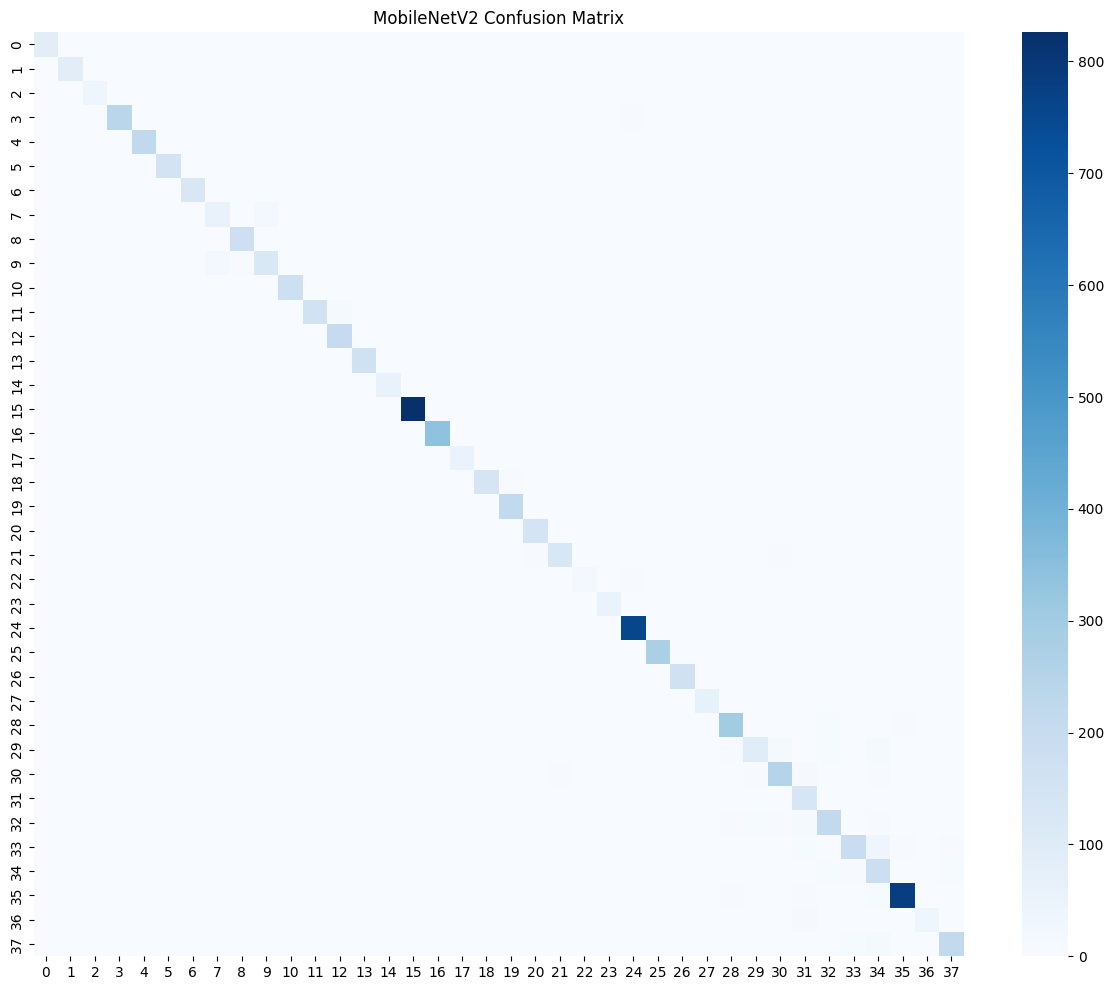

In [25]:
# from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(15,12))

sns.heatmap(cm, cmap='Blues')

plt.title("MobileNetV2 Confusion Matrix")

plt.savefig("../graphs/mobilenetv2_confusion_matrix.png")

plt.show()

In [26]:
mobilenet_model.save("../models/final_mobilenetv2.keras")

DenseNet121

In [7]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [8]:
base_model = DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
densenet_model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(train_data.num_classes, activation='softmax')
])

In [11]:
densenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
checkpoint = ModelCheckpoint(
    "../models/best_densenet121.keras",
    monitor='val_accuracy',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [14]:
history_dense = densenet_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2778s 2s/step - accuracy: 0.7156 - loss: 1.0718 - val_accuracy: 0.8492 - val_loss: 0.6075 - learning_rate: 1.0000e-04
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2732s 2s/step - accuracy: 0.8061 - loss: 0.6974 - val_accuracy: 0.8894 - val_loss: 0.4198 - learning_rate: 1.0000e-04
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2851s 2s/step - accuracy: 0.8425 - loss: 0.5456 - val_accuracy: 0.9087 - val_loss: 0.3361 - learning_rate: 1.0000e-04
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2771s 2s/step - accuracy: 0.8661 - loss: 0.4537 - val_accuracy: 0.9203 - val_loss: 0.2867 - learning_rate: 1.0000e-04
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2872s 2s/step - accuracy: 0.8813 - loss: 0.3988 - val_accuracy: 0.9293 - val_loss: 0.2477 - learning_rate: 1.0000e-04
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 2872s 2s/step - accuracy: 0.8933 - loss: 0.3557 - val_accuracy: 0.9369 - val_loss: 0.2224 - learning_rate: 1.0000e-04
Epoch 7/10
1188/1188 ━━━━━━━━━━━━━━━━━━━

In [15]:
loss, accuracy = densenet_model.evaluate(test_data)

print("DenseNet121 Test Accuracy:", accuracy)

256/256 ━━━━━━━━━━━━━━━━━━━━ 550s 2s/step - accuracy: 0.9544 - loss: 0.1566
DenseNet121 Test Accuracy: 0.9543954133987427


In [16]:
from sklearn.metrics import classification_report
import numpy as np

predictions = densenet_model.predict(test_data)

pred_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_labels = list(test_data.class_indices.keys())

dense_report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
)

print(dense_report)

256/256 ━━━━━━━━━━━━━━━━━━━━ 542s 2s/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.97      0.87      0.92        95
                                 Apple___Black_rot       0.99      0.98      0.98        94
                          Apple___Cedar_apple_rust       0.95      0.86      0.90        42
                                   Apple___healthy       0.95      0.99      0.97       248
                               Blueberry___healthy       0.99      0.99      0.99       226
          Cherry_(including_sour)___Powdery_mildew       0.99      0.97      0.98       159
                 Cherry_(including_sour)___healthy       1.00      0.98      0.99       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.82      0.76      0.79        78
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       180
               Corn_(maize)___Norther

In [17]:
with open("../reports/densenet121_classification_report.txt", "w") as f:
    f.write(dense_report)

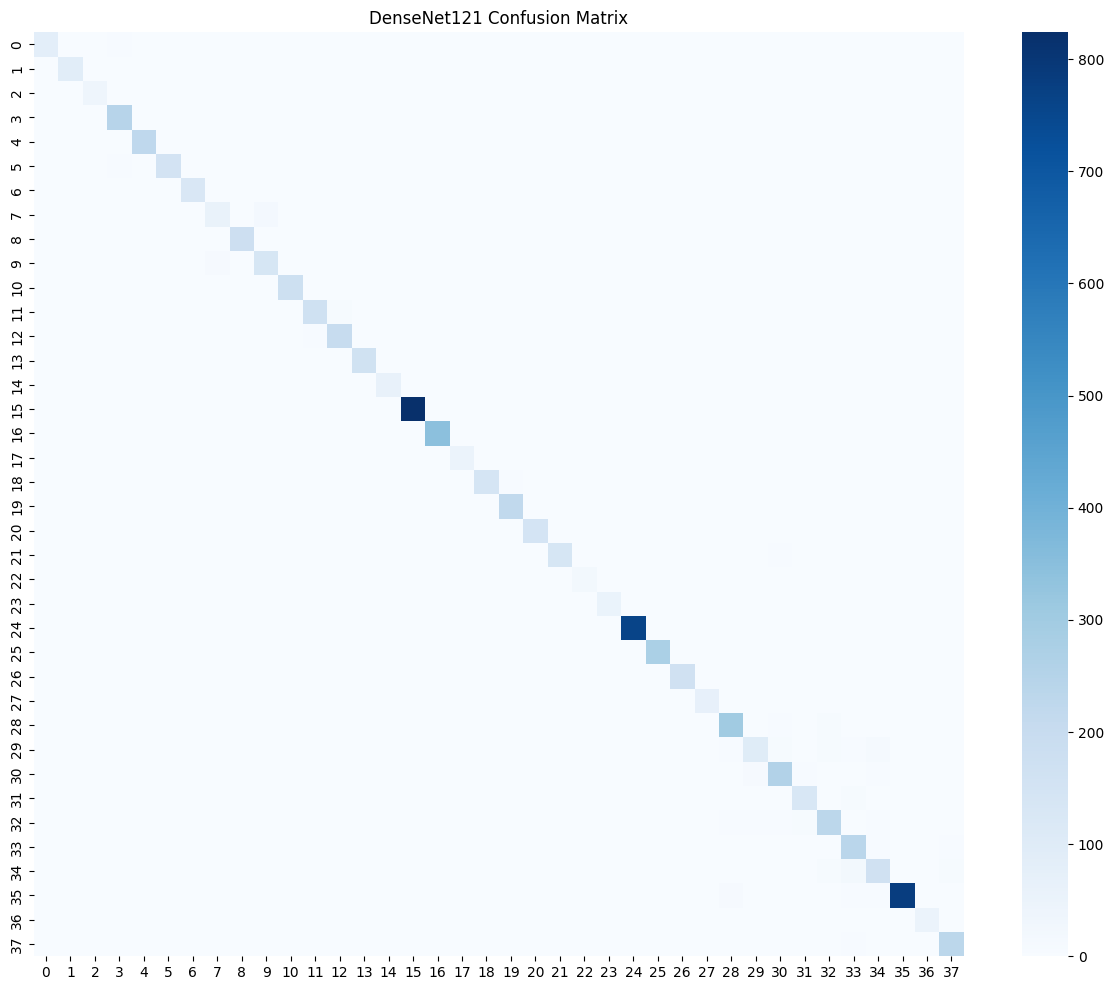

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("DenseNet121 Confusion Matrix")

plt.savefig(
    "../graphs/densenet121_confusion_matrix.png"
)

plt.show()

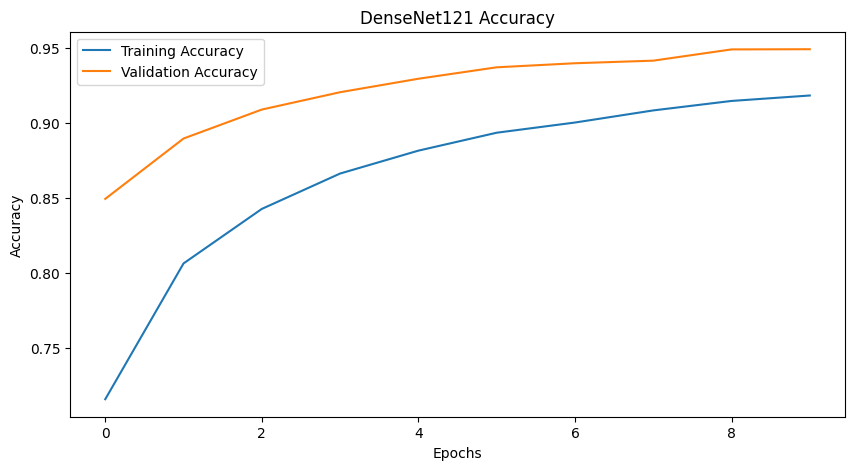

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    history_dense.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_dense.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("DenseNet121 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig(
    "../graphs/densenet121_accuracy.png"
)

plt.show()

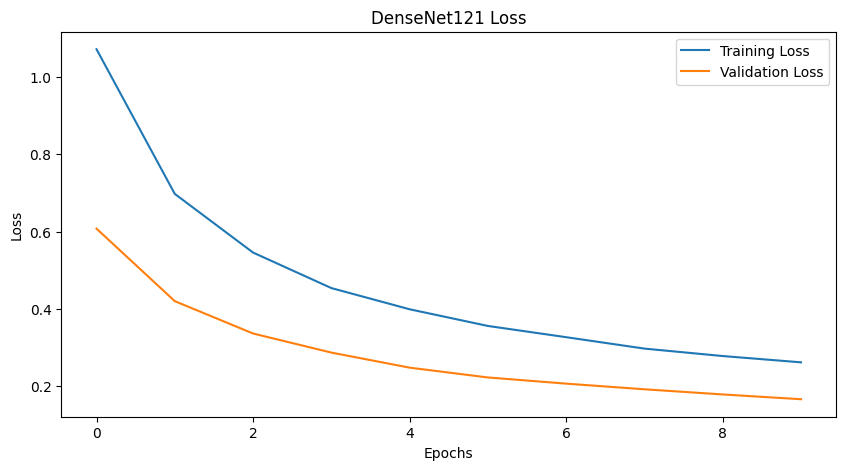

In [20]:
plt.figure(figsize=(10,5))

plt.plot(
    history_dense.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_dense.history['val_loss'],
    label='Validation Loss'
)

plt.title("DenseNet121 Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.savefig(
    "../graphs/densenet121_loss.png"
)

plt.show()

In [21]:
import pandas as pd

history_df = pd.DataFrame(
    history_dense.history
)

history_df.to_csv(
    "../reports/densenet121_training_history.csv",
    index=False
)

print("Training History Saved")

Training History Saved


In [7]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D

In [8]:
base_model = InceptionV3(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 377s 4us/step


In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
inception_model = Sequential([
    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(train_data.num_classes, activation='softmax')
])

In [11]:
inception_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
checkpoint = ModelCheckpoint(
    "../models/best_inceptionv3.keras",
    monitor='val_accuracy',
    save_best_only=True
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [13]:
history_inception = inception_model.fit(
    train_data,
    validation_data=valid_data,
    epochs=10,
    callbacks=[early_stop, reduce_lr, checkpoint]
)

Epoch 1/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1284s 1s/step - accuracy: 0.5395 - loss: 1.7609 - val_accuracy: 0.7537 - val_loss: 0.9354 - learning_rate: 1.0000e-04
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1265s 1s/step - accuracy: 0.7378 - loss: 0.9238 - val_accuracy: 0.8261 - val_loss: 0.6459 - learning_rate: 1.0000e-04
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1216s 1s/step - accuracy: 0.7898 - loss: 0.7149 - val_accuracy: 0.8452 - val_loss: 0.5415 - learning_rate: 1.0000e-04
Epoch 4/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1175s 989ms/step - accuracy: 0.8182 - loss: 0.6118 - val_accuracy: 0.8673 - val_loss: 0.4543 - learning_rate: 1.0000e-04
Epoch 5/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1179s 992ms/step - accuracy: 0.8333 - loss: 0.5477 - val_accuracy: 0.8759 - val_loss: 0.4202 - learning_rate: 1.0000e-04
Epoch 6/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1178s 992ms/step - accuracy: 0.8466 - loss: 0.4985 - val_accuracy: 0.8825 - val_loss: 0.3882 - learning_rate: 1.0000e-04
Epoch 7/10
1188/1188 ━━━━━━━━━━

In [14]:
loss, accuracy = inception_model.evaluate(test_data)

print("InceptionV3 Test Accuracy:", accuracy)

256/256 ━━━━━━━━━━━━━━━━━━━━ 209s 815ms/step - accuracy: 0.8951 - loss: 0.3285
InceptionV3 Test Accuracy: 0.8950971961021423


In [15]:
from sklearn.metrics import classification_report
import numpy as np

predictions = inception_model.predict(test_data)

pred_classes = np.argmax(predictions, axis=1)

true_classes = test_data.classes

class_labels = list(test_data.class_indices.keys())

inception_report = classification_report(
    true_classes,
    pred_classes,
    target_names=class_labels
)

print(inception_report)

256/256 ━━━━━━━━━━━━━━━━━━━━ 207s 792ms/step
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.85      0.73      0.78        95
                                 Apple___Black_rot       0.87      0.90      0.89        94
                          Apple___Cedar_apple_rust       0.91      0.74      0.82        42
                                   Apple___healthy       0.95      0.84      0.89       248
                               Blueberry___healthy       0.94      0.97      0.96       226
          Cherry_(including_sour)___Powdery_mildew       0.97      0.94      0.96       159
                 Cherry_(including_sour)___healthy       0.98      0.92      0.95       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.80      0.77      0.78        78
                       Corn_(maize)___Common_rust_       0.96      0.99      0.98       180
               Corn_(maize)___Nort

In [16]:
with open("../reports/inceptionv3_classification_report.txt", "w") as f:
    f.write(inception_report)

print("Classification Report Saved")

Classification Report Saved


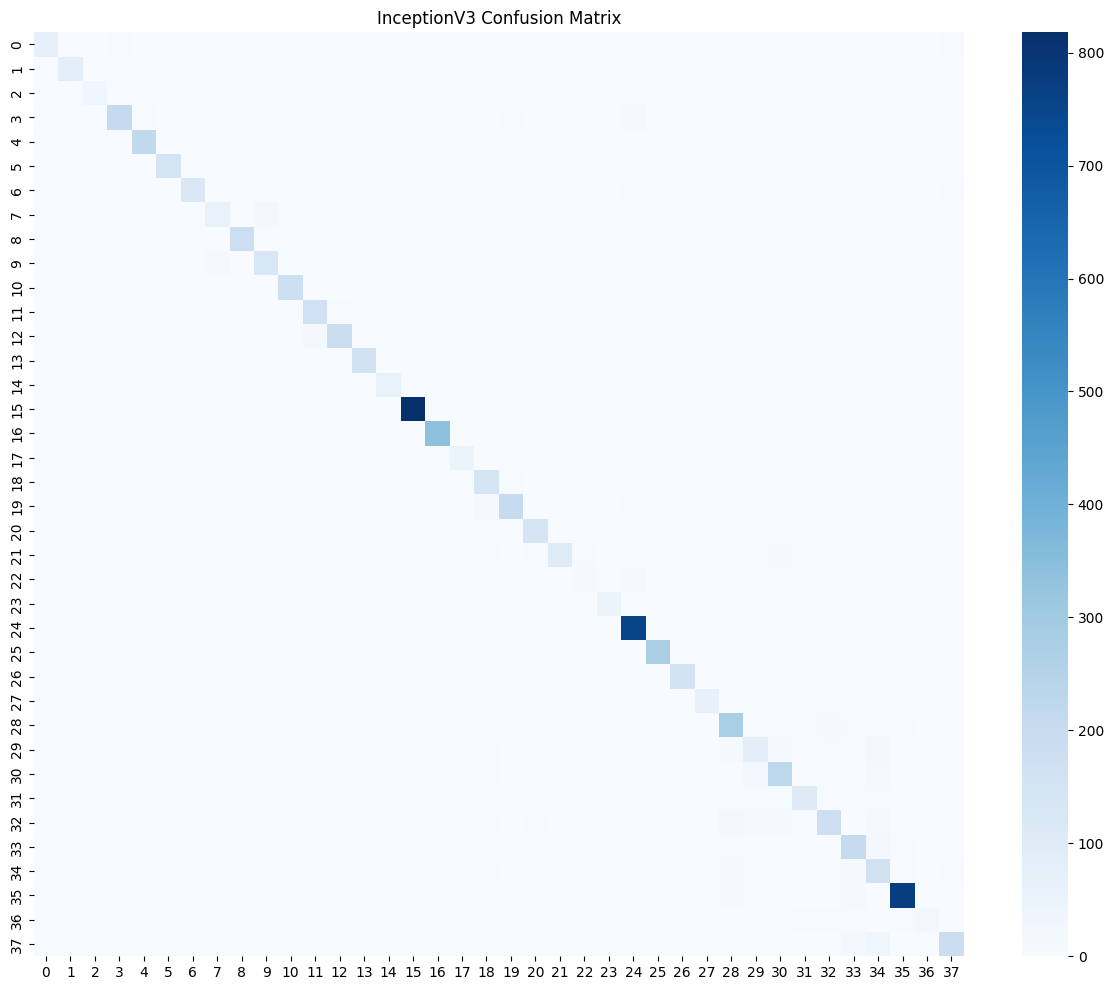

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    true_classes,
    pred_classes
)

plt.figure(figsize=(15,12))

sns.heatmap(
    cm,
    cmap="Blues"
)

plt.title("InceptionV3 Confusion Matrix")

plt.savefig(
    "../graphs/inceptionv3_confusion_matrix.png"
)

plt.show()

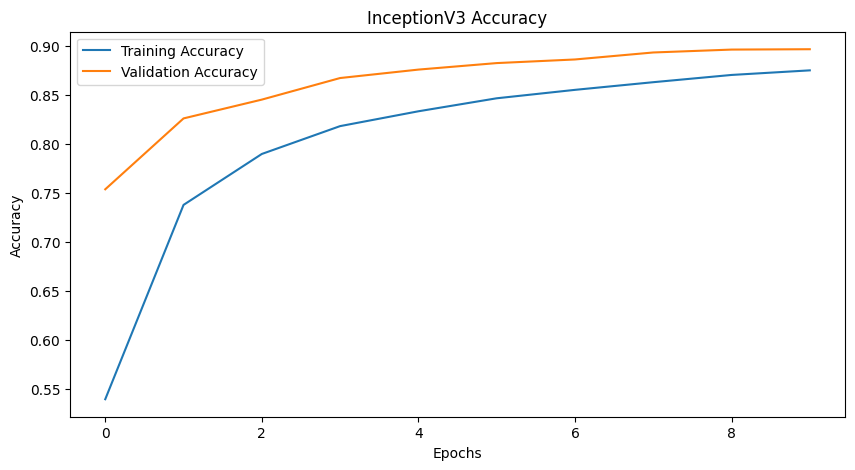

In [18]:
plt.figure(figsize=(10,5))

plt.plot(
    history_inception.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history_inception.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title("InceptionV3 Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()

plt.savefig(
    "../graphs/inceptionv3_accuracy.png"
)

plt.show()

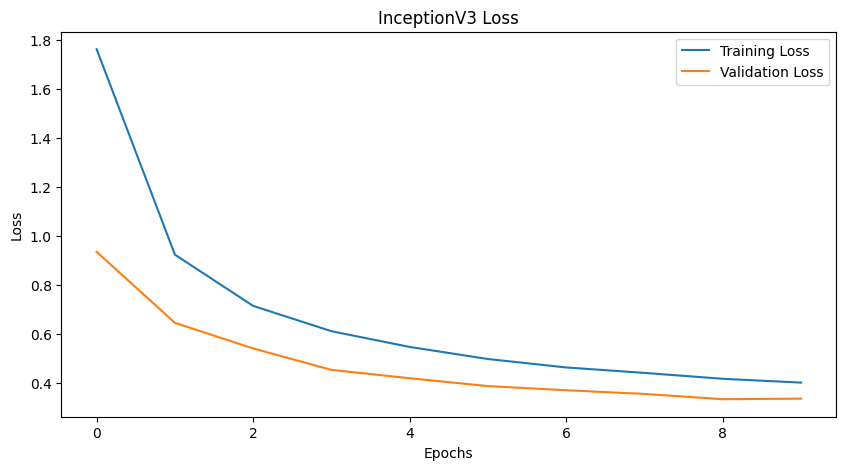

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    history_inception.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_inception.history['val_loss'],
    label='Validation Loss'
)

plt.title("InceptionV3 Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()

plt.savefig(
    "../graphs/inceptionv3_loss.png"
)

plt.show()

In [20]:
inception_model.save(
    "../models/final_inceptionv3.keras"
)

print("Model Saved Successfully")

Model Saved Successfully


In [21]:
import pandas as pd

history_df = pd.DataFrame(
    history_inception.history
)

history_df.to_csv(
    "../reports/inceptionv3_training_history.csv",
    index=False
)

print("Training History Saved")

Training History Saved


In [22]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "ResNet50",
        "MobileNetV2",
        "DenseNet121",
        "InceptionV3"
    ],
    "Test Accuracy (%)": [
        44.38,
        94.13,
        95.44,
        89.51
    ]
})

print(comparison)

comparison.to_csv(
    "../reports/model_comparison.csv",
    index=False
)

         Model  Test Accuracy (%)
0     ResNet50              44.38
1  MobileNetV2              94.13
2  DenseNet121              95.44
3  InceptionV3              89.51


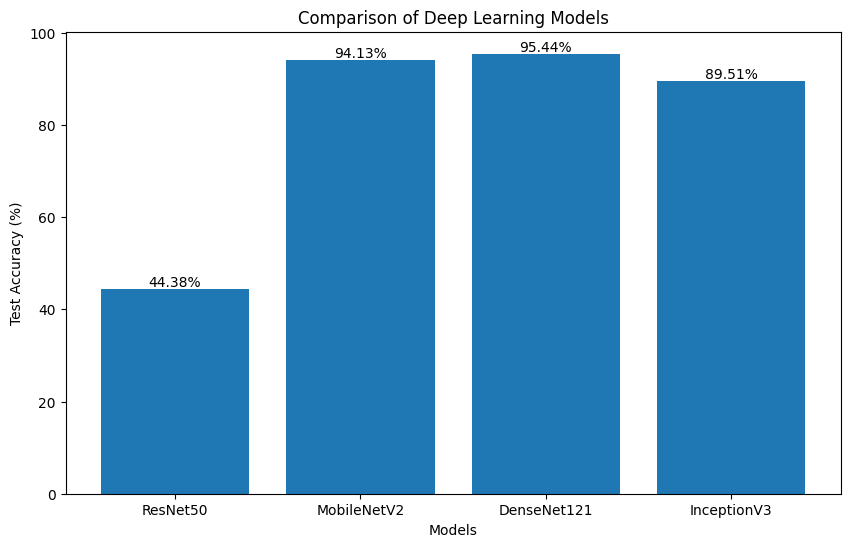

In [23]:
import matplotlib.pyplot as plt

models = [
    "ResNet50",
    "MobileNetV2",
    "DenseNet121",
    "InceptionV3"
]

accuracies = [
    44.38,
    94.13,
    95.44,
    89.51
]

plt.figure(figsize=(10,6))

bars = plt.bar(models, accuracies)

plt.title("Comparison of Deep Learning Models")
plt.xlabel("Models")
plt.ylabel("Test Accuracy (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.5,
        f"{height:.2f}%",
        ha='center'
    )

plt.savefig(
    "../graphs/final_model_comparison.png"
)

plt.show()

In [24]:
summary = pd.DataFrame({
    "Model": [
        "ResNet50",
        "MobileNetV2",
        "DenseNet121",
        "InceptionV3"
    ],
    "Accuracy (%)": [
        44.38,
        94.13,
        95.44,
        89.51
    ],
    "Rank": [
        4,
        2,
        1,
        3
    ]
})

print(summary)

summary.to_csv(
    "../reports/final_performance_summary.csv",
    index=False
)

         Model  Accuracy (%)  Rank
0     ResNet50         44.38     4
1  MobileNetV2         94.13     2
2  DenseNet121         95.44     1
3  InceptionV3         89.51     3


In [26]:
import os

print(os.getcwd())

c:\Users\Sumit\OneDrive\Desktop\Plant-Disease-Detection\notebooks


In [27]:
import os

print(os.listdir())

['plant_disease_detection.ipynb']


In [28]:
print(os.listdir("../models"))

['best_densenet121.keras', 'best_efficientnetb0.keras', 'best_inceptionv3.keras', 'best_mobilenetv2.keras', 'best_resnet50.keras', 'final_inceptionv3.keras', 'final_mobilenetv2.keras']


In [29]:
from tensorflow.keras.models import load_model

model = load_model("../models/best_densenet121.keras")

In [30]:
model.save("../models/final_densenet121.keras")

print("DenseNet121 saved successfully")

DenseNet121 saved successfully


In [34]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("../models/final_densenet121.keras")

class_labels = list(test_data.class_indices.keys())

def predict_disease(img_path):
    
    img = image.load_img(img_path, target_size=(224,224))
    
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0

    prediction = model.predict(img_array, verbose=0)[0]

    disease = class_labels[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    print("\nTop 5 Predictions:")
    
    top5_idx = np.argsort(prediction)[-5:][::-1]

    for idx in top5_idx:
        print(f"{class_labels[idx]} : {prediction[idx]*100:.2f}%")

    print("\nFinal Prediction:")
    print("Disease:", disease)
    print(f"Confidence: {confidence:.2f}%")

In [44]:
predict_disease(r"C:\Users\Sumit\Downloads\grape4.jpg")


Top 5 Predictions:
Grape___Esca_(Black_Measles) : 96.72%
Grape___Black_rot : 3.19%
Grape___healthy : 0.04%
Apple___Apple_scab : 0.01%
Apple___Black_rot : 0.01%

Final Prediction:
Disease: Grape___Esca_(Black_Measles)
Confidence: 96.72%
